## Depurar las cuatro fuentes: faltantes y atípicos

**Fase 3 · limpieza y cruzamiento (guía).** Aquí las fuentes dejan de verse tan ordenadas como en el cuaderno anterior: se buscan duplicados, se tipan las columnas y, sobre todo, se decide qué hacer con los huecos (faltantes) y con los valores extremos. Para lo primero se usa la clasificación **MCAR / MAR / MNAR**; para lo segundo se comparan **IQR y z-score** antes de elegir un método.

In [1]:
import sys
from pathlib import Path
_ROOT = Path.cwd()
while not any((_ROOT / c).exists() for c in ['db', 'data']) and _ROOT != _ROOT.parent:
    _ROOT = _ROOT.parent
sys.path.insert(0, str(_ROOT / 'script'))
from proyecto import graficos
display(graficos.fig_fases())

<Figure size 1344x364 with 1 Axes>

## 1. Buscar la raíz del proyecto

In [2]:
%matplotlib inline
import sys
from pathlib import Path

import numpy as np
import pandas as pd
from IPython.display import display

PROYECTO = Path.cwd()
while not any((PROYECTO / c).exists() for c in ['db', 'data']) and PROYECTO != PROYECTO.parent:
    PROYECTO = PROYECTO.parent

sys.path.insert(0, str(PROYECTO / 'script'))
from proyecto import config
from proyecto import (cargar, limpiar, diagnostico, transformaciones, cruces,
                      indicadores, validacion, graficos)

def presentar(fig):
    display(fig)

print('raiz del proyecto:', PROYECTO.name)
print('fuentes en data/crudo:', [p.name for p in config.DATA_CRUDO.glob('*.csv')])

raiz del proyecto: mineria
fuentes en data/crudo: ['Average_UK_houseprices_and_salary.csv', 'Income_by_age_and_gender.csv', 'MET_Office_Weather_Data.csv', 'UK_Mortgage_Rate.csv']


## 2. Duplicados y contratos de tipos

Antes de hablar de huecos, hay que ver si un mismo registro aparece dos veces y si las columnas están en el tipo correcto. Las claves naturales son `sku+tid` (un producto hipotecario por escaneo) y `anio+mes+estacion` (una lectura mensual por estación).

In [3]:
h = cargar.cargar_hipotecas(); c = cargar.cargar_clima()
p = cargar.cargar_precios_salario(); i = cargar.cargar_ingreso_edad()
print('F2 duplicados sku+tid:', int(h.duplicated(['sku', 'tid']).sum()))
print('F3 duplicados anio+mes+estacion:', int(c.duplicated(['anio', 'mes', 'estacion']).sum()))
print('F3 filas sin fecha (corruptas):', int(c['anio'].isna().sum()))
print('F4 ingresos duplicados:', int(i.duplicated(['grupo_edad', 'genero']).sum()))

F2 duplicados sku+tid: 0
F3 duplicados anio+mes+estacion: 10
F3 filas sin fecha (corruptas): 20
F4 ingresos duplicados: 0


## 3. Datos faltantes: MCAR, MAR o MNAR

No basta con contar vacíos; hay que preguntarse *por qué* faltan:

- **MCAR**: la ausencia no depende de nada que se esté midiendo (imputar no sesgaría).
- **MAR**: la ausencia depende de otra variable ya observada.
- **MNAR**: la ausencia depende del propio valor o del diseño de la fuente (imputar sería fabricar historia).

In [4]:
h_limpio, d1 = limpiar.limpiar_hipotecas(h.copy())
c_limpio, d2 = limpiar.limpiar_clima(c.copy())
p_limpio, d3 = limpiar.limpiar_precios_salario(p.copy())
i_limpio, d4 = limpiar.limpiar_ingreso_edad(i.copy())
clas = diagnostico.clasificacion_fuentes({'hipotecas': h, 'clima': c, 'precios': p})
display(clas)

,fuente,columna,nulos,pct,clasificacion,evidencia,tratamiento
0,F2 hipotecas,tasa_reversion,328,4.21,MAR,la ausencia depende del tipo (observado): disc...,conservar NaN (la cuota usa tasa_inicial; reve...
1,F3 clima,anio/month,20,0.05,MNAR,filas sin fecha (registro corrupto/footer),eliminar fila (no son mediciones)
2,F3 clima,tmax,1599,4.32,MCAR,gaps instrumentales de estacion: 1467/1599 con...,NaN (los agregados anuales y la normal toleran...
3,F3 clima,tmin,1522,4.11,MCAR,gaps instrumentales de estacion: 1467/1599 con...,NaN (los agregados anuales y la normal toleran...
4,F3 clima,af,2949,7.96,MCAR,gaps instrumentales de estacion: 1467/1599 con...,NaN (los agregados anuales y la normal toleran...
5,F3 clima,lluvia,1478,3.99,MCAR,gaps instrumentales de estacion: 1467/1599 con...,NaN (los agregados anuales y la normal toleran...
6,F3 clima,sol,9483,25.60,MNAR estructural,horas de sol no medidas/publicadas antes de 19...,"NaN (la anomalia de sol se usa aparte, solo do..."
7,F4 precios/salario,salario_mediana_real,24,52.17,MNAR estructural,mediana salarial no publicada hasta 1999 (seri...,NaN (no se imputa historia inventada)


### Qué tan serios son los casos

El caso más interesante es la tasa de reversión de las hipotecas: no es un error del archivo, sino que depende del tipo de producto (los de tasa variable la omiten casi el 40 % de las veces, los fijos casi nunca). En el clima, las temperaturas y la lluvia se pierden en bloque cuando una estación deja de reportar; el sol sencillamente no se publicó antes de 1931. Y el salario solo existe desde 1999. Por eso se conservan los vacíos en vez de rellenarlos.

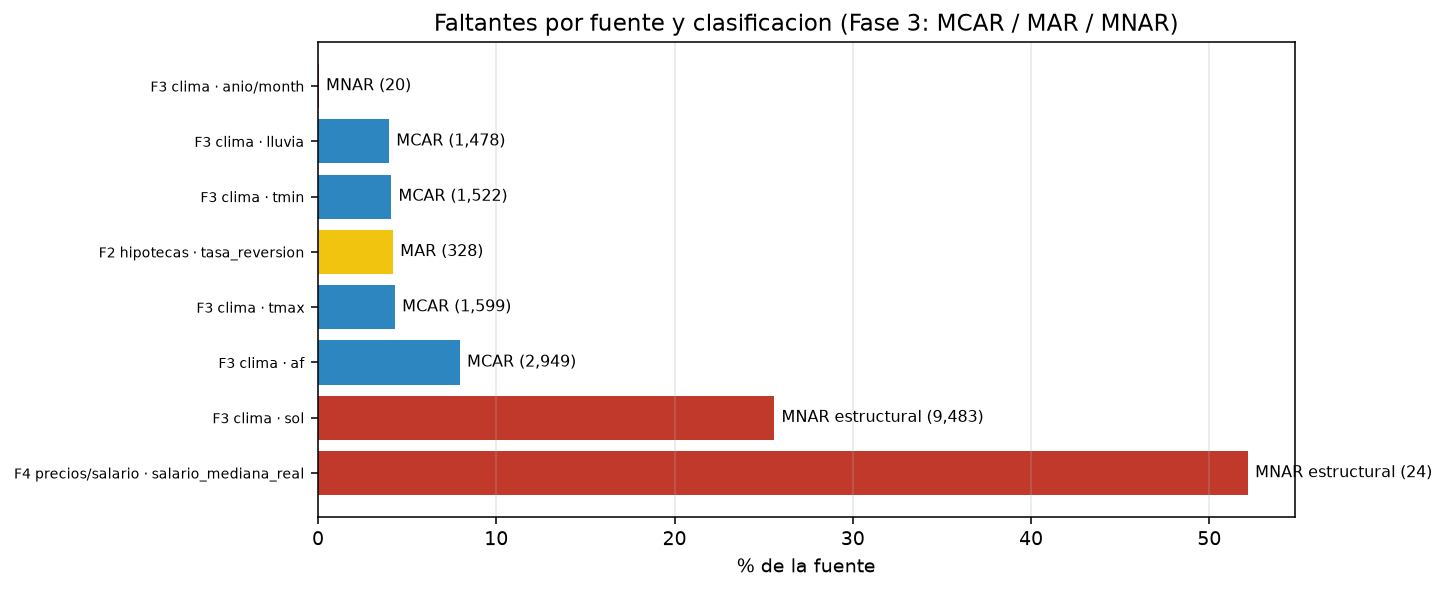

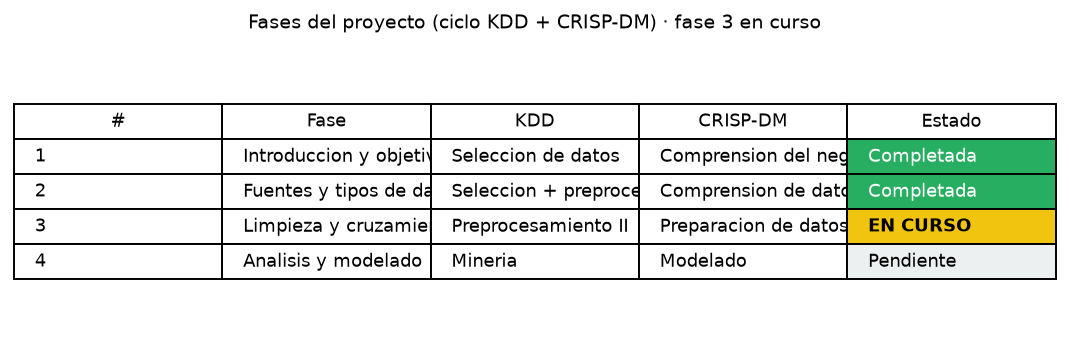

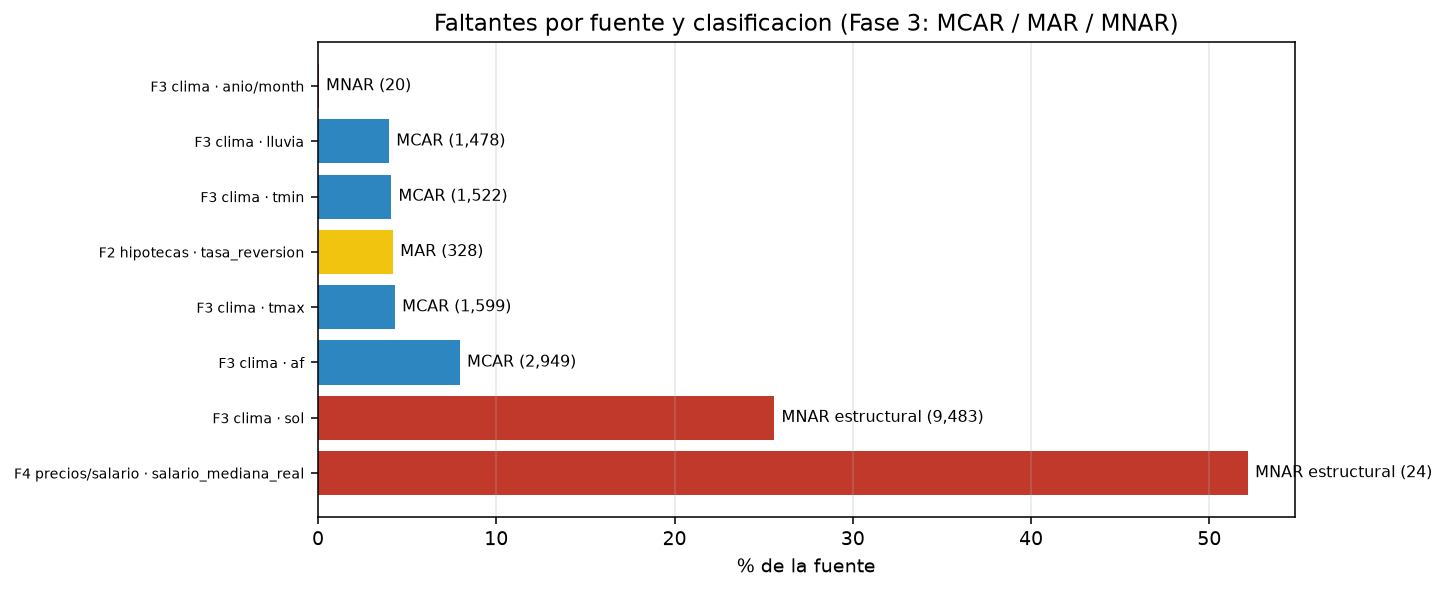

In [5]:
presentar(graficos.fig_nulos_fuentes(clas))

## 4. Atípicos en la tasa inicial: IQR contra z-score

La tasa inicial alimenta la cuota hipotecaria del cuaderno 04, así que conviene mirarla bien. El z-score solo hace su trabajo si los datos son más o menos normales; el IQR (Tukey) no lo exige.

In [6]:
tasa = h_limpio['tasa_inicial_pct'].astype('float64')
ev = diagnostico.comparar_iqr_zscore(tasa, 'tasa_inicial_pct')
print(f"Q1={ev['q1']} mediana={ev['mediana']} Q3={ev['q3']} | IQR={ev['iqr']}")
print(f"limite IQR {ev['lim_sup']}: fuera {ev['fuera_iqr']:,} ({ev['pct_iqr']} %)  "
      f"| z-score >3: {ev['fuera_z']} ({ev['pct_z']} %)  |  skew={ev['skew']}")
print('-> ' + ev['razon'])

Q1=5.62 mediana=6.1 Q3=6.62 | IQR=1.0
limite IQR 8.13: fuera 762 (9.77 %)  | z-score >3: 0 (0.0 %)  |  skew=0.04
-> IQR no supone normalidad y detecta la cola real aun con skew=0.04; el z-score con |z|>3 no detecta nada (0). Se winsoriza al limite superior.


tasa media: original 6.113 -> winsorizada 6.043


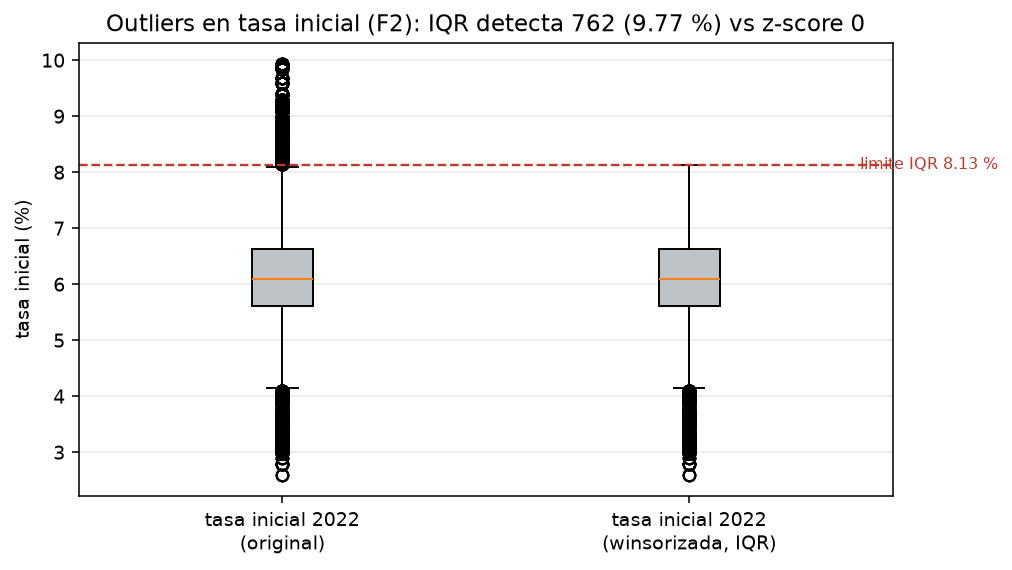

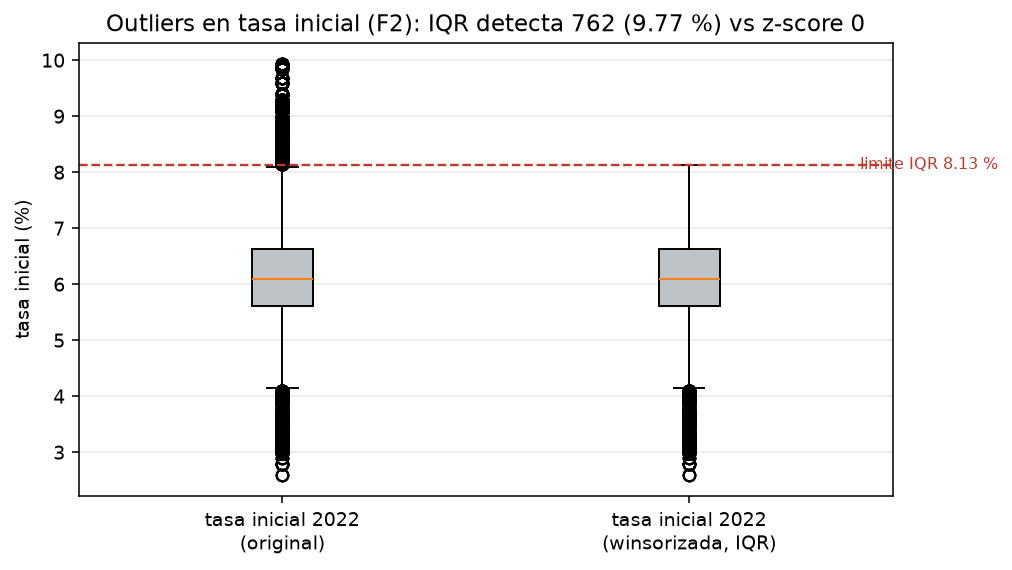

In [7]:
lim = diagnostico.limites_iqr(tasa)['limite_superior']
tasa_w = diagnostico.winsorizar(tasa, lim)
h_limpio['tasa_inicial_pct'] = tasa_w
h_limpio['es_atipico_tasa'] = tasa > lim
print('tasa media: original %.3f -> winsorizada %.3f' % (tasa.mean(), tasa_w.mean()))
presentar(graficos.fig_outliers_tasa(tasa, tasa_w, ev))

### Por qué quedarse con el IQR

El z-score con |z| > 3 no detecta *ningún* atípico en 7.796 productos, pese a que hay una cola real hasta el 9,94 %. El IQR, en cambio, marca 762 (9,77 %) por encima del límite de 8,13. Como no conviene sacar filas, se **winsoriza** (se llevan esos valores al límite) y se deja la bandera `es_atipico_tasa` por si la necesitamos después. El mismo criterio se usó con el precio de F1 en su fase.

## 5. Problemas encontrados, de un vistazo

| Fuente | Problema | Cantidad | Clase | Tratamiento |
|---|---|---|---|---|
| F2 | tasa_reversion nula | 328 (4,2 %) | MAR | conservar NaN (informativa) |
| F2 | atípicos de tasa | 762 (9,8 %) | — | winsorizar con IQR |
| F3 | filas corruptas sin fecha | 20 | MNAR | eliminar |
| F3 | tmax/tmin/af/lluvia nulos | 4-8 % | MCAR | NaN (agregados toleran) |
| F3 | sol sin publicar < 1931 | 9.483 (25,6 %) | MNAR estructural | NaN |
| F4 | salario antes de 1999 | 24 (52 %) | MNAR estructural | NaN (no imputar) |
| F4b | bandas sin corte en 34 | — | aprox. | media de medianas 18-21/22-29/30-39 |

## Resumiendo

Cada decisión de esta depuración quedó registrada en `md/BITACORA_DECISIONES.md` con su evidencia, para que se pueda revisar y repetir. Siguiente paso: dejar las fuentes listas para cruzar (cuaderno 03).